## Tendencia de la demanda de habilidades para Data Analysts

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast 
import locale

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

df_DA

In [ ]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

df_DA

In [ ]:
df_DA_explode = df_DA.explode('job_skills')

df_DA_explode['job_skills'] = df_DA_explode['job_skills'].str.capitalize()

df_DA_explode

In [20]:
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

In [21]:
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]

In [22]:
df_DA_pivot = df_DA_pivot.drop('Total')

In [ ]:
df_DA_pivot.iloc[:,:5]

In [ ]:
df_DA_pivot.plot(kind='line', legend=False)

In [25]:
DA_total = df_DA.groupby('job_posted_month_no').size()

In [26]:
df_DA_perc = df_DA_pivot.div(DA_total/100, 0)

In [ ]:
df_DA_perc = df_DA_perc.reset_index()
df_DA_perc['job_posted_month'] = df_DA_perc['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b')) 
df_DA_perc = df_DA_perc.set_index('job_posted_month')
df_DA_perc = df_DA_perc.drop(columns='job_posted_month_no')

df_DA_perc

In [ ]:
locale.setlocale(locale.LC_ALL, 'es_ES.UTF-8')

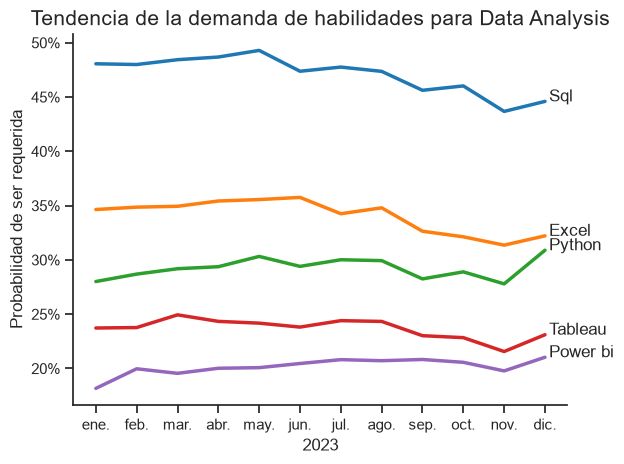

In [34]:
df_plot = df_DA_perc.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False, palette='tab10', linewidth=2.5)
sns.set_theme(style='ticks')
sns.despine()

plt.title('Tendencia de la demanda de habilidades para Data Analysis', fontsize=15)
plt.legend().remove()
plt.ylabel('Probabilidad de ser requerida')
plt.xlabel('2023')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

txt = []

for i in range(5):
    t = plt.text(11.1, df_plot.iloc[-1, i], df_plot.columns[i])
    txt.append(t)



plt.tight_layout()
plt.show()

